# Exploratory Data Analysis (EDA)

In this notebook, we perform a deep exploratory data analysis on the cleaned Algerian Forest Fires dataset. Our goal is to uncover statistical patterns, feature interactions, and potential anomalies to inform our feature engineering and model selection strategy.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Set professional visual guidelines
sns.set_theme(style="whitegrid", palette="magma")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the cleaned dataset
df = pd.read_csv('../data/processed/algerian_forest_fire_cleaned.csv')
df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


## Class Imbalance Check


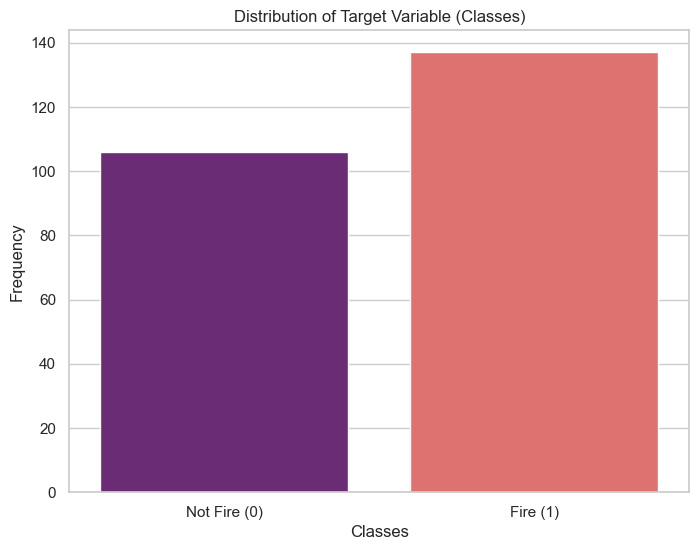

Class Distribution:
 Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Classes', palette='magma')
plt.title('Distribution of Target Variable (Classes)')
plt.xticks([0, 1], ['Not Fire (0)', 'Fire (1)'])
plt.ylabel('Frequency')
plt.show()

print("Class Distribution:\n", df['Classes'].value_counts(normalize=True) * 100)


**What the graph shows:** A bar chart displaying the frequency of the two target classes: 'Not Fire' (0) and 'Fire' (1). The printed output shows the exact percentage breakdown.

**Patterns/Trends:** The dataset contains slightly more 'Fire' instances (~56%) compared to 'Not Fire' (~44%). 

**ML Implications:** The dataset is relatively well-balanced. We will not need aggressive class balancing techniques like SMOTE or heavy class weighting during model training, as accuracy will remain a reliable metric.


# Univariate Analysis

We will analyze the distributions of our continuous independent variables. We split them into Meteorological Features and Fire Weather Indices.


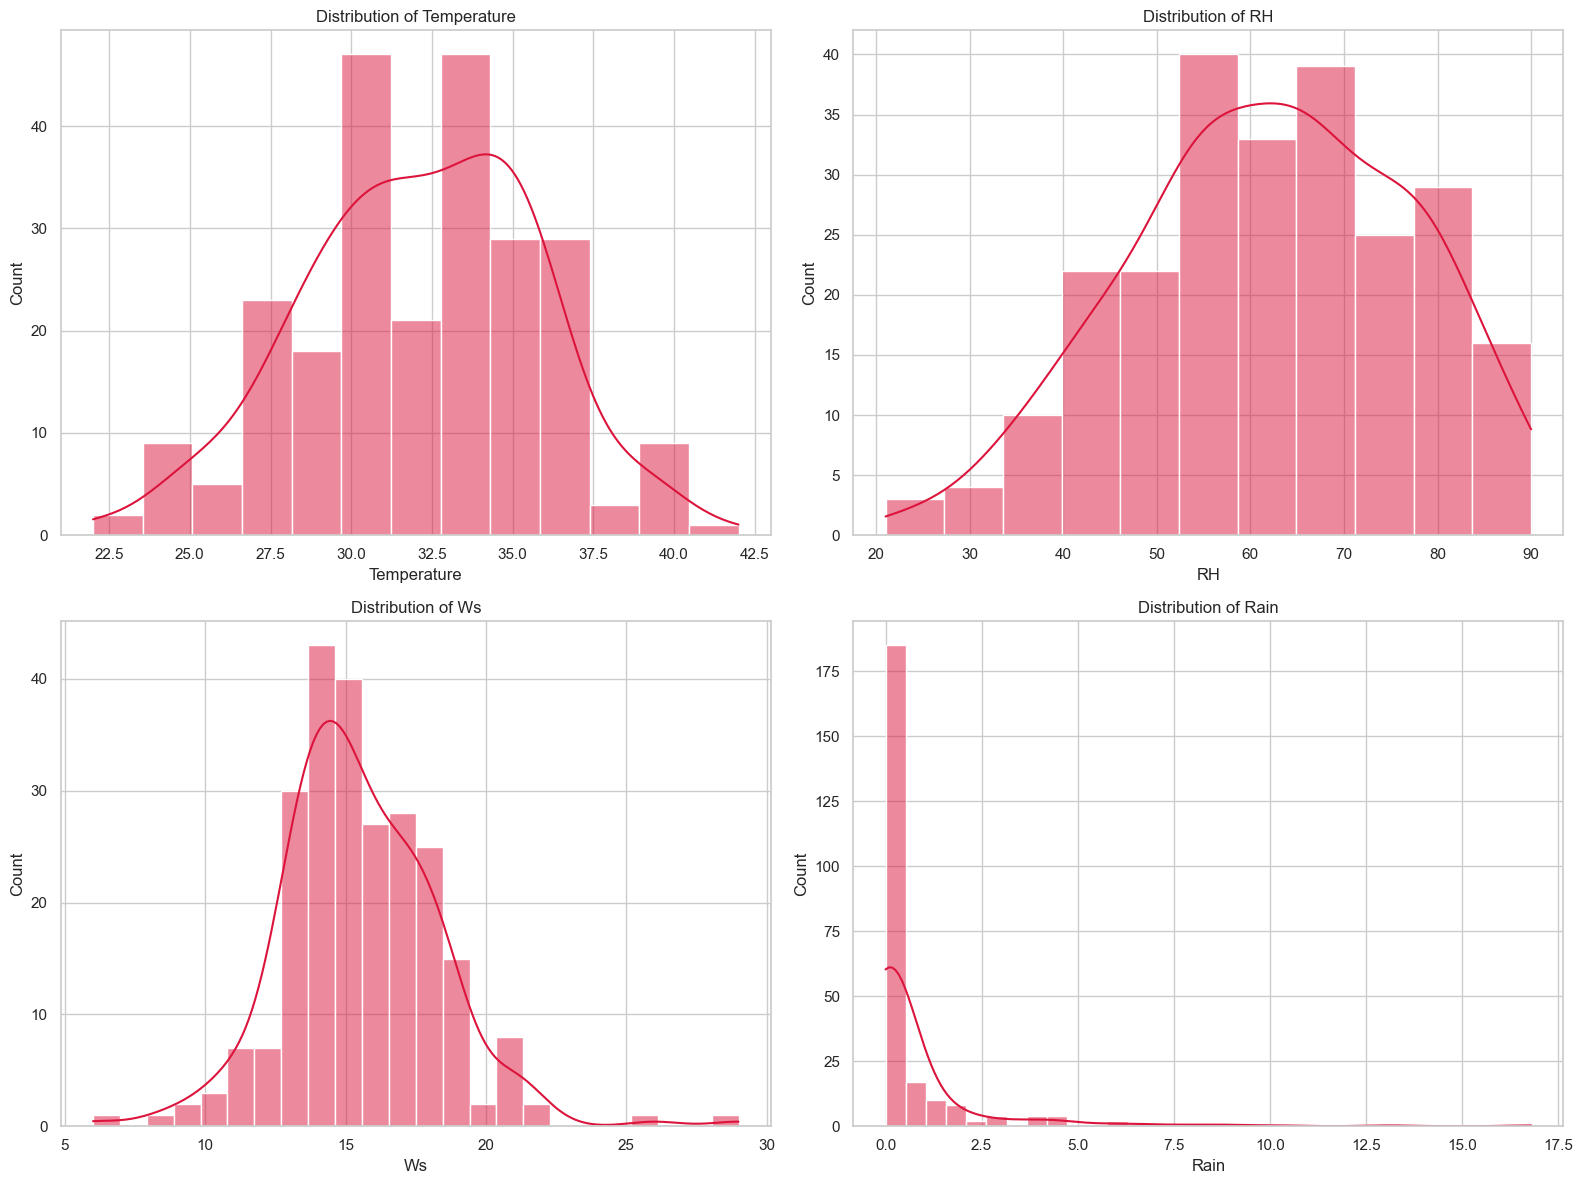

In [4]:
# Meteorological Features
met_features = ['Temperature', 'RH', 'Ws', 'Rain']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, feature in enumerate(met_features):
    row, col = i // 2, i % 2
    sns.histplot(df[feature], kde=True, ax=axes[row, col], color='crimson')
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()


**What the graph shows:** Histograms with overlaid Kernel Density Estimates (KDE) for the four core meteorological observations (Temperature, Relative Humidity, Wind Speed, and Rain).

**Patterns/Trends:** 
- `Temperature`, `RH` (Relative Humidity), and `Ws` (Wind Speed) approximate a normal/Gaussian distribution. 
- `Rain` is heavily right-skewed, with the vast majority of observations concentrated at 0 (no rain).

**ML Implications:** The heavy skew in `Rain` means distance-based algorithms (like KNN) or linear models might struggle with it. We may need to apply a non-linear transformation (like Log1p) or bin the `Rain` feature into categorical bins (e.g., "No Rain", "Light Rain", "Heavy Rain"). The other features can safely be standardized.


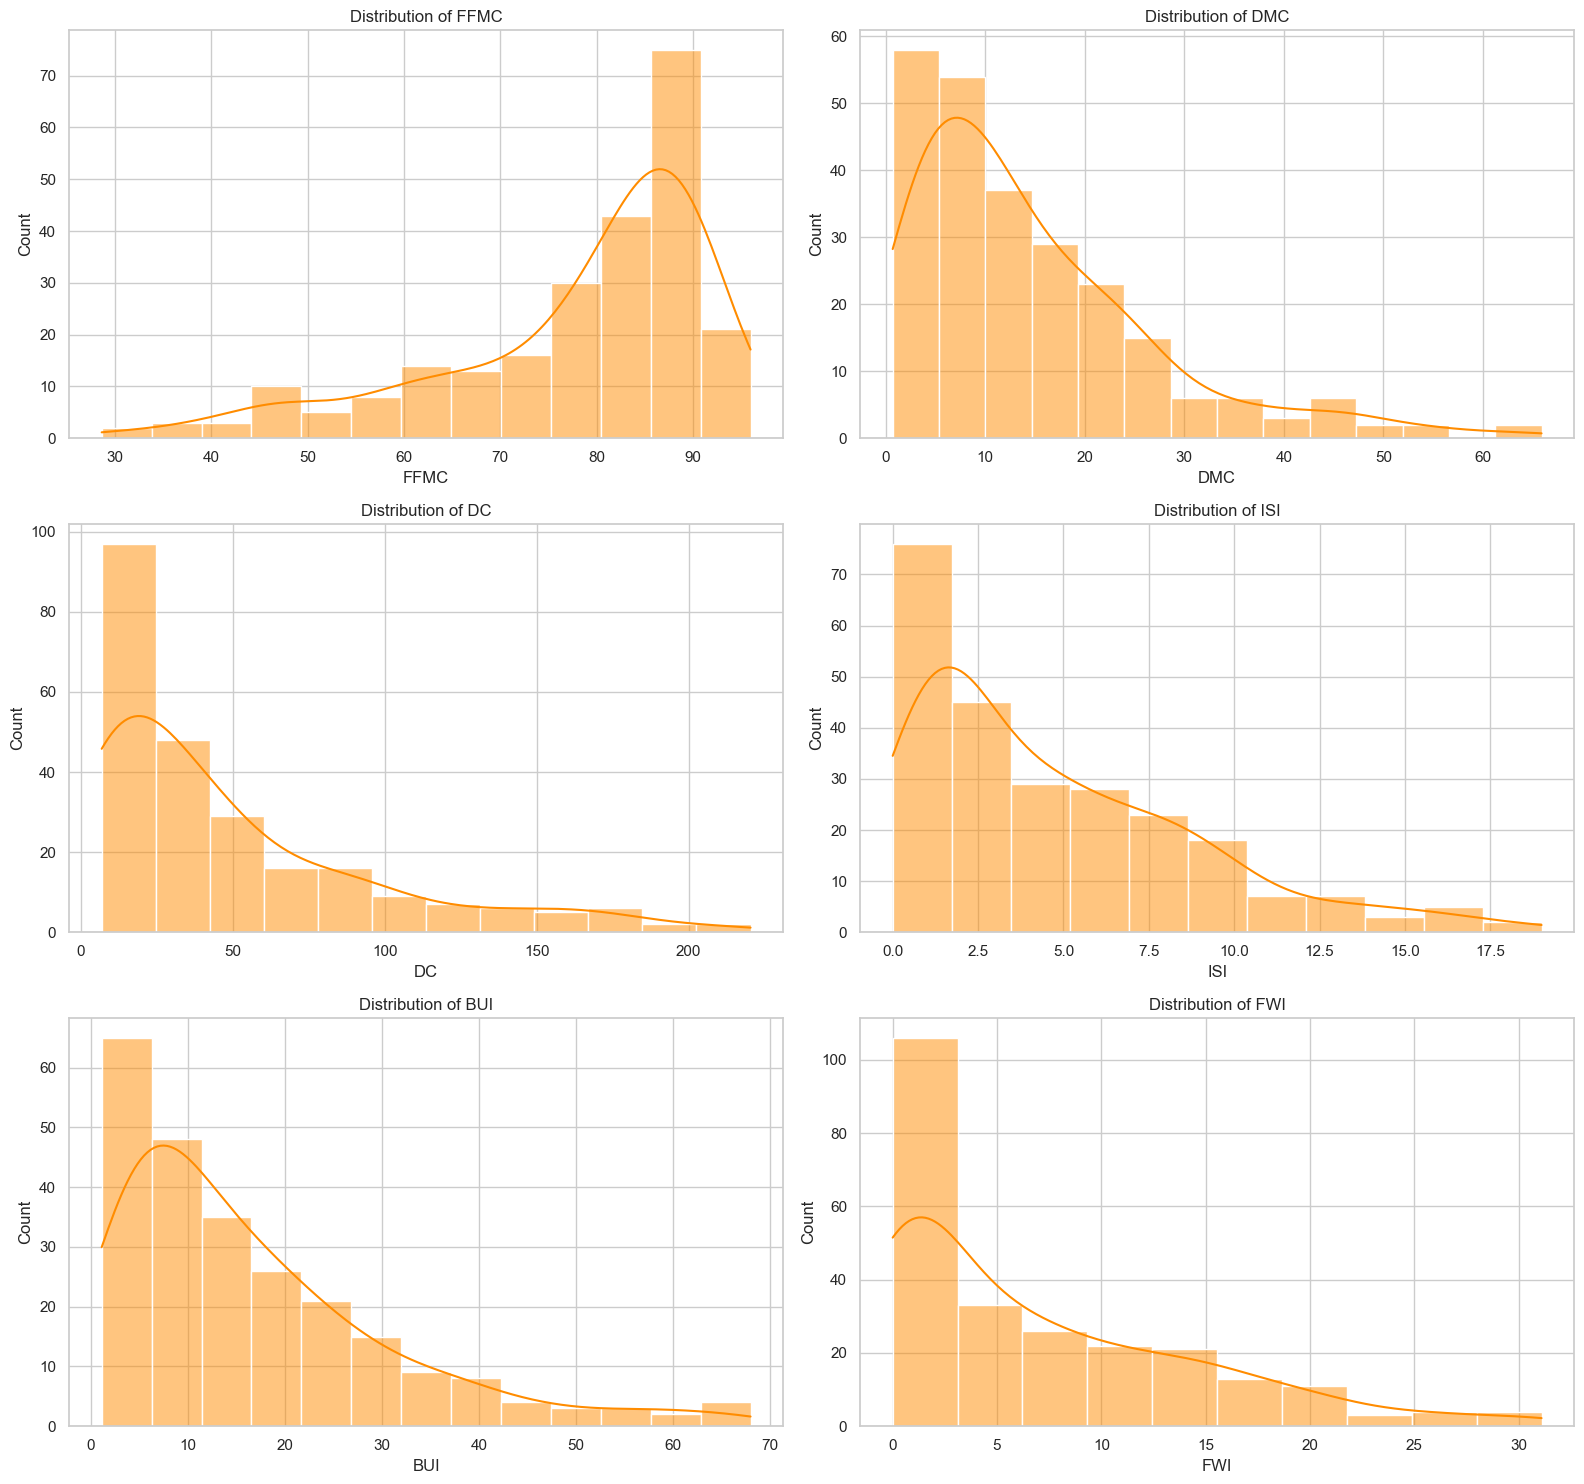

In [5]:
# Fire Weather Indices
fwi_features = ['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for i, feature in enumerate(fwi_features):
    row, col = i // 2, i % 2
    sns.histplot(df[feature], kde=True, ax=axes[row, col], color='darkorange')
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()


**What the graph shows:** Histograms and KDE plots for the six derived Fire Weather Indices.

**Patterns/Trends:** 
- `FFMC` is strongly left-skewed.
- `DMC`, `DC`, `ISI`, `BUI`, and `FWI` are all distinctly right-skewed.

**ML Implications:** The widespread skewness across these calculated indices confirms that scaling and transformation will be critical. Linear Regression models expect normally distributed residuals, so applying Box-Cox or Logarithmic transformations to these right-skewed features will likely improve model performance and stability.


## Outlier Detection


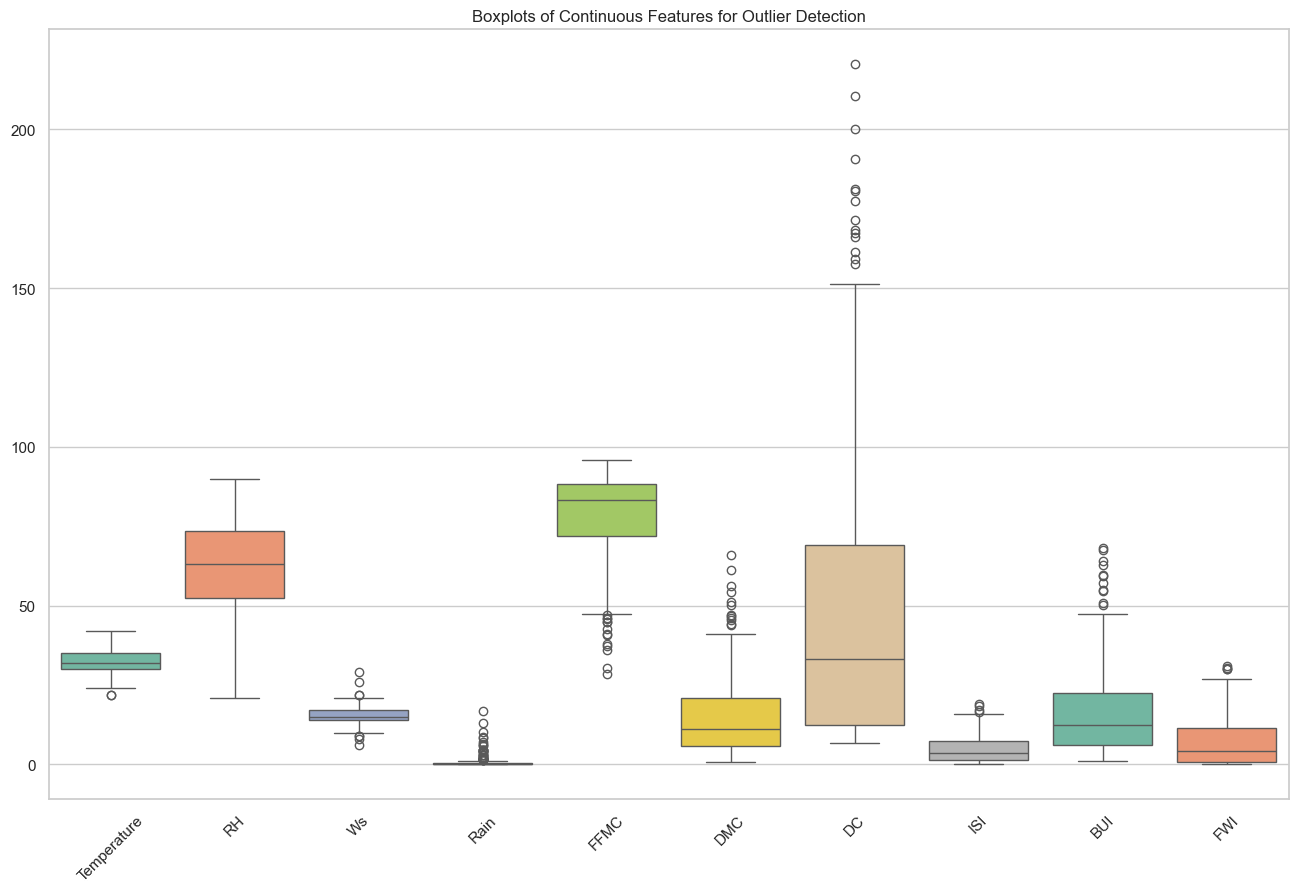

In [6]:
# Outlier detection using Boxplots
continuous_features = met_features + fwi_features

plt.figure(figsize=(16, 10))
sns.boxplot(data=df[continuous_features], palette='Set2')
plt.title('Boxplots of Continuous Features for Outlier Detection')
plt.xticks(rotation=45)
plt.show()


**What the graph shows:** Box-and-whisker plots representing the spread, median, quartiles, and explicit outliers (the dots) for all continuous features.

**Patterns/Trends:** 
- `DC` (Drought Code) and `BUI` (Buildup Index) have massive scales compared to others, and a few notable outliers on the upper end.
- `Rain`, `Ws`, `FFMC`, and `ISI` contain distinct outliers. 

**ML Implications:** We have two main takeaways. First, the drastic scale difference mandates standardizing our data (e.g., using `StandardScaler`). Second, the presence of real, naturally occurring outliers (like a very rainy day) means we should consider robust scaling methods (like `RobustScaler` which uses the IQR) or algorithms that are naturally robust to outliers, such as Random Forests or Gradient Boosting.


# Bivariate Analysis

Let's explore how our features behave concerning the target variable (`Classes`).


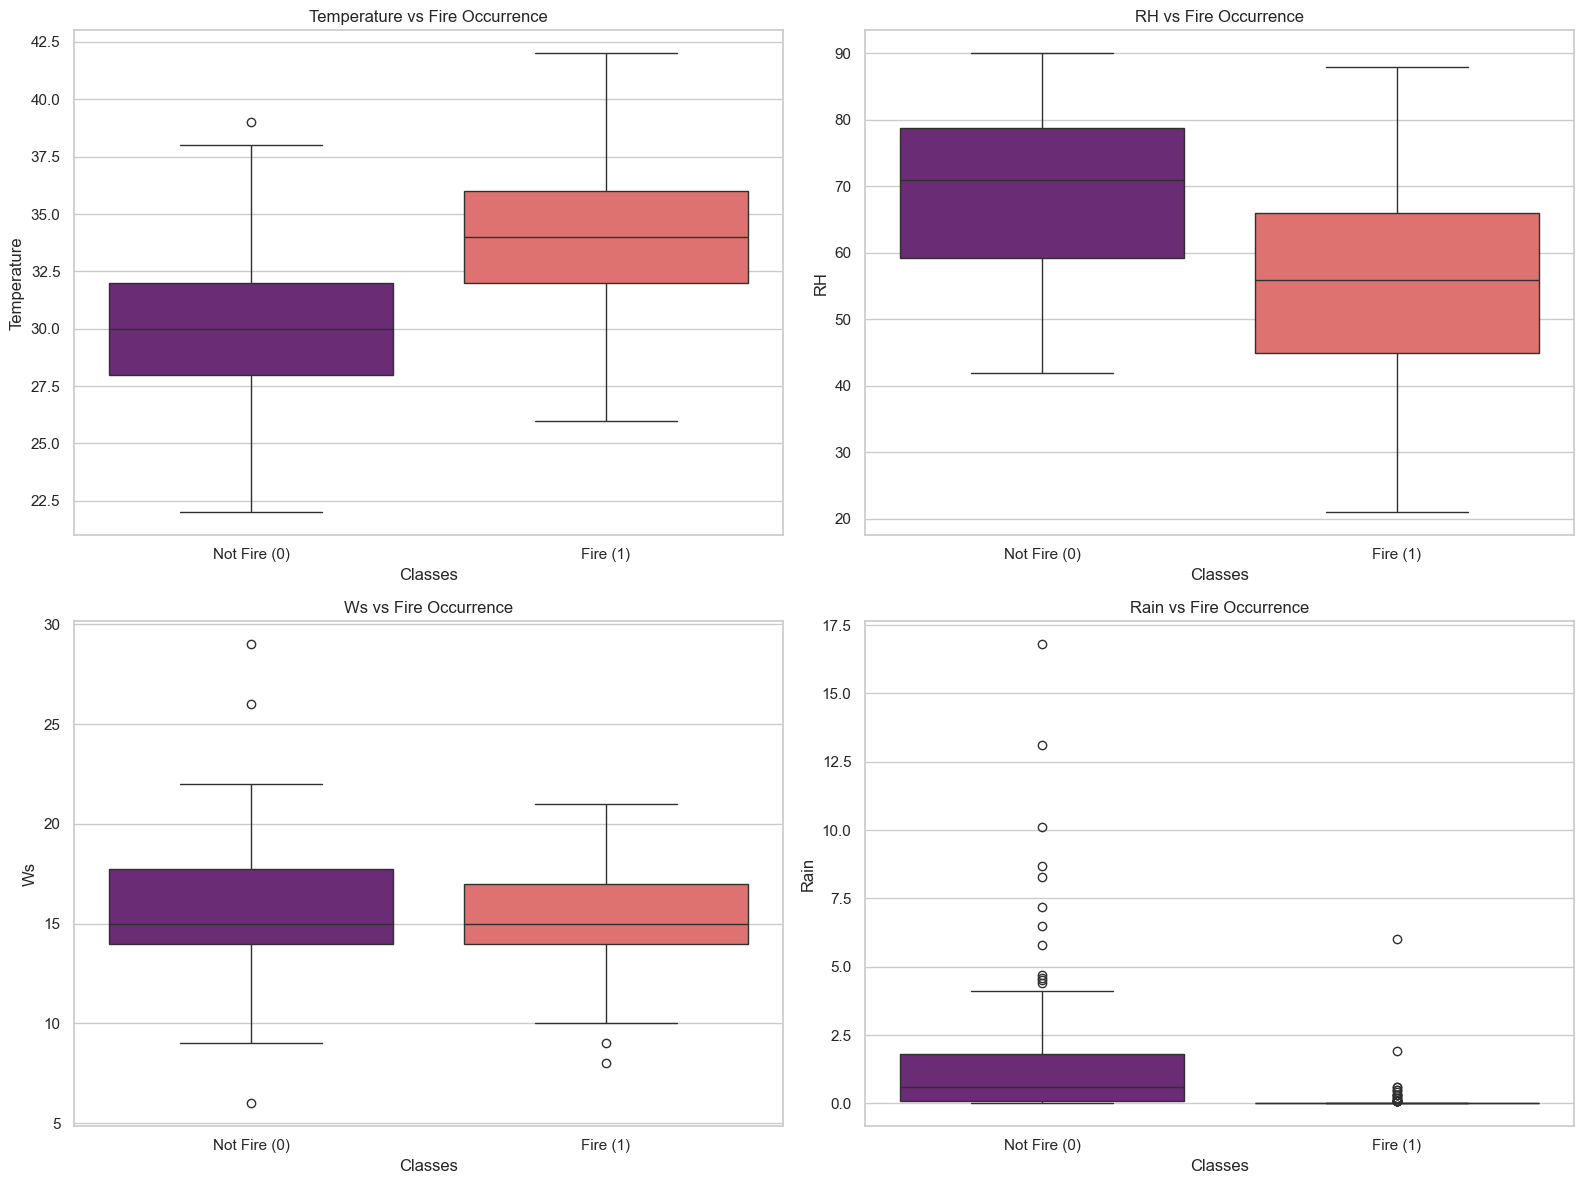

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, feature in enumerate(met_features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='Classes', y=feature, palette='magma', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs Fire Occurrence')
    axes[row, col].set_xticks([0, 1])
    axes[row, col].set_xticklabels(['Not Fire (0)', 'Fire (1)'])

plt.tight_layout()
plt.show()


**What the graph shows:** Boxplots illustrating the distribution of the four meteorological features segmented by whether a fire occurred (1) or did not occur (0).

**Patterns/Trends:** 
- **Temperature:** Higher temperatures are clearly associated with 'Fire'.
- **RH (Relative Humidity):** Lower humidity is strongly associated with 'Fire'.
- **Rain:** Fire almost exclusively occurs when rainfall is effectively zero.
- **Ws (Wind Speed):** Shows little to no distinct separation between the two classes.

**ML Implications:** `Temperature`, `RH`, and `Rain` are highly discriminative features and will be powerful predictors for our classification models. `Wind Speed` (`Ws`) alone appears to be a weak predictor, but we should retain it as it may have strong interactive effects with other variables.


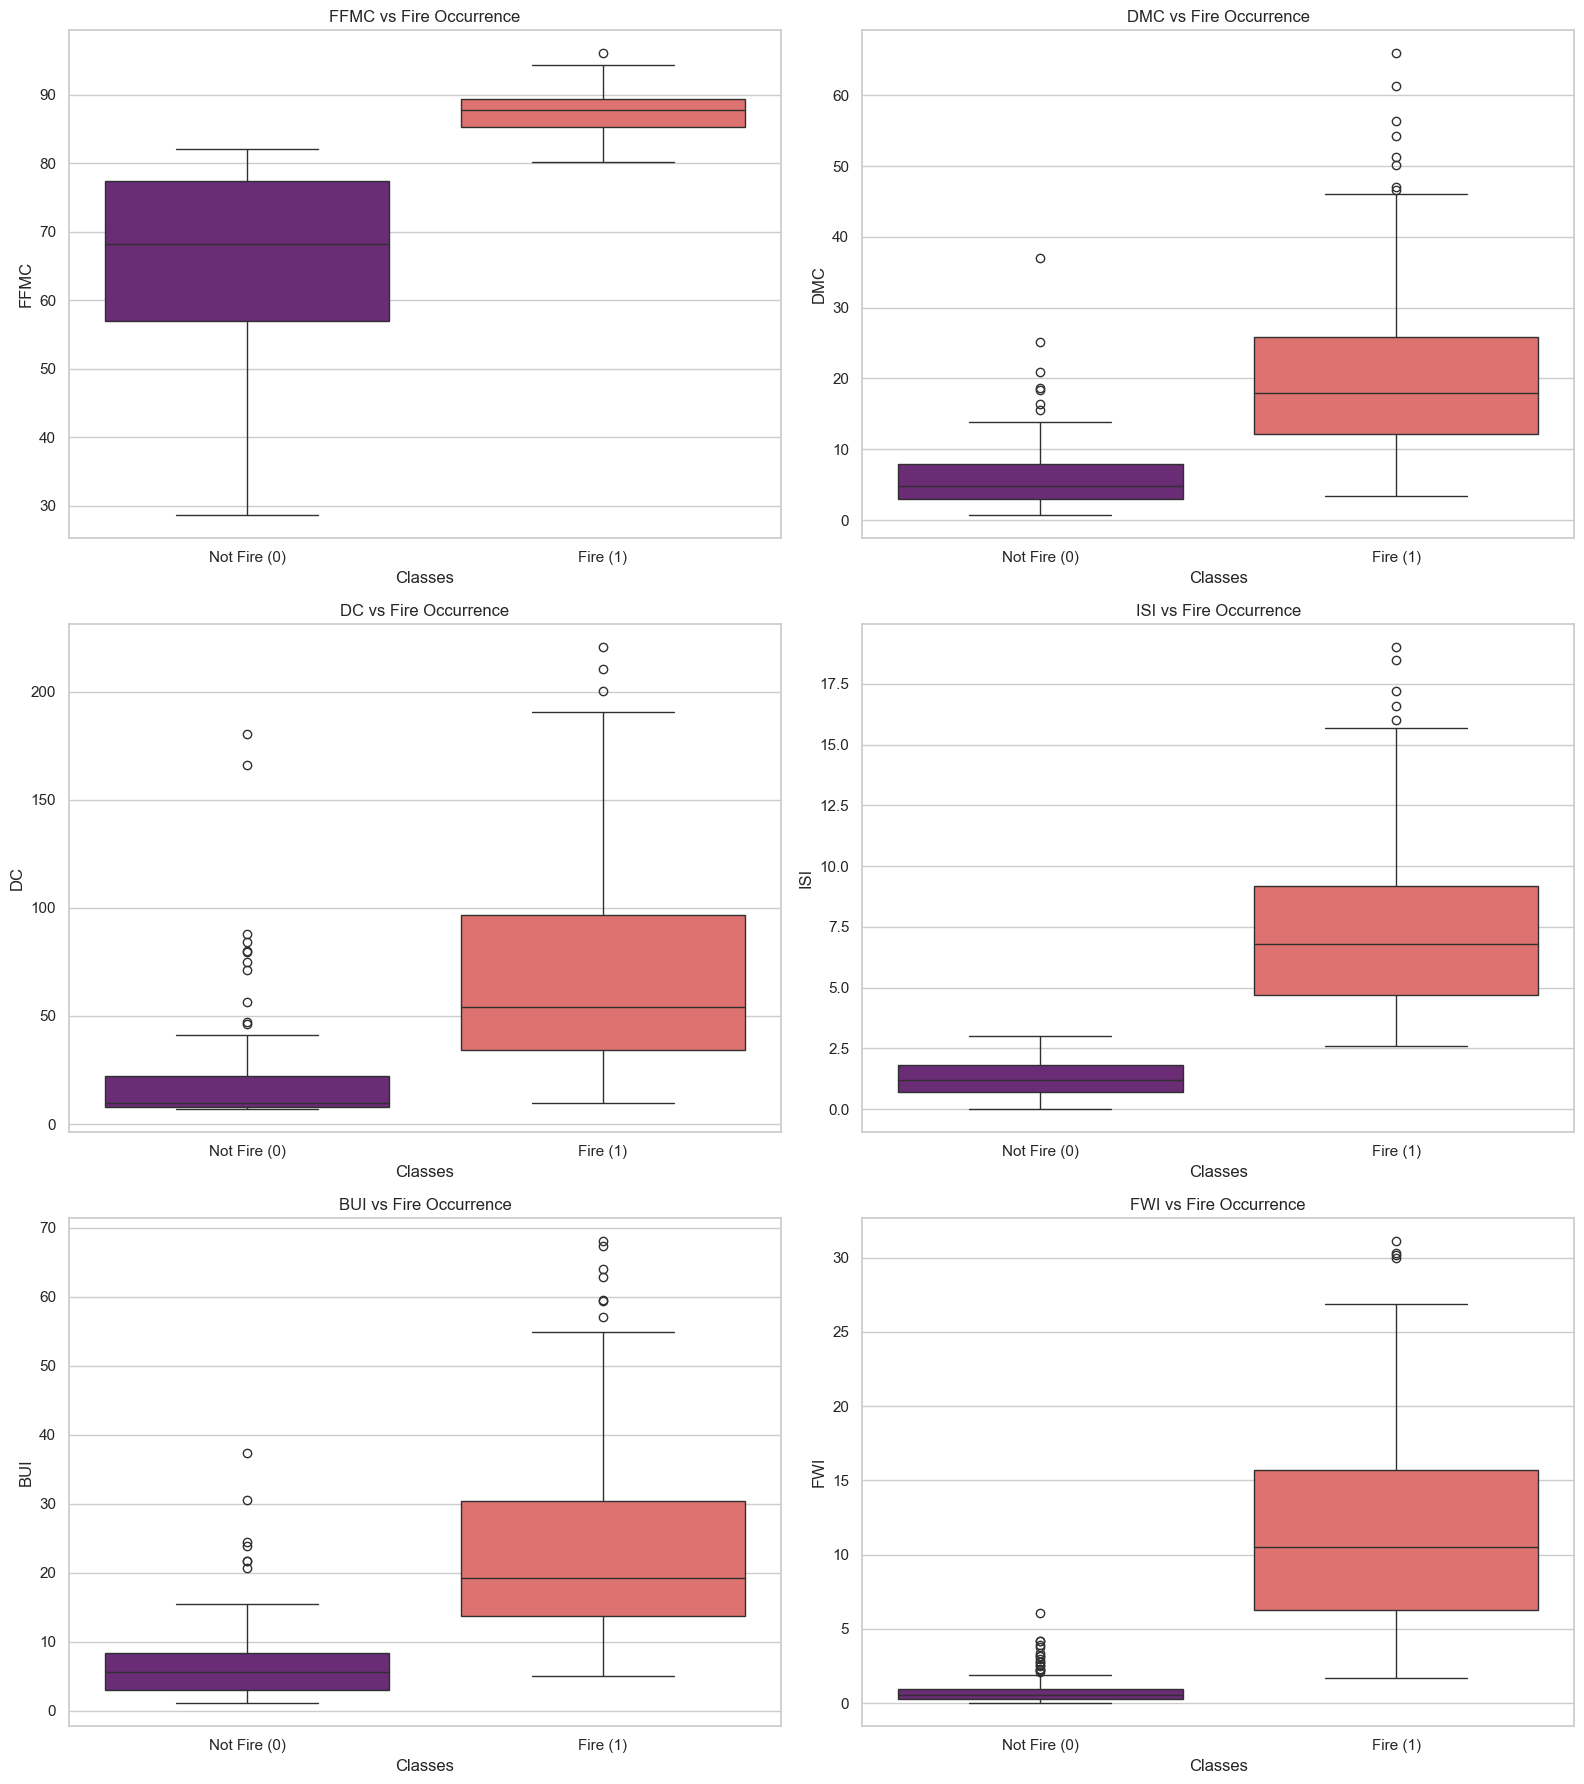

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
for i, feature in enumerate(fwi_features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='Classes', y=feature, palette='magma', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs Fire Occurrence')
    axes[row, col].set_xticks([0, 1])
    axes[row, col].set_xticklabels(['Not Fire (0)', 'Fire (1)'])

plt.tight_layout()
plt.show()


**What the graph shows:** Boxplots for the six Fire Weather Indices categorized by the target variable.

**Patterns/Trends:** There is an extraordinary level of separation across all indices. High values of `FFMC`, `DMC`, `DC`, `ISI`, `BUI`, and `FWI` are nearly absolute indicators of a fire event. 

**ML Implications:** These indices are engineered specifically to predict fires, and the data confirms their effectiveness. Because the classes are so easily separable along these dimensions, even simple models like Logistic Regression or shallow Decision Trees should achieve very high accuracy.


# Feature Relationships


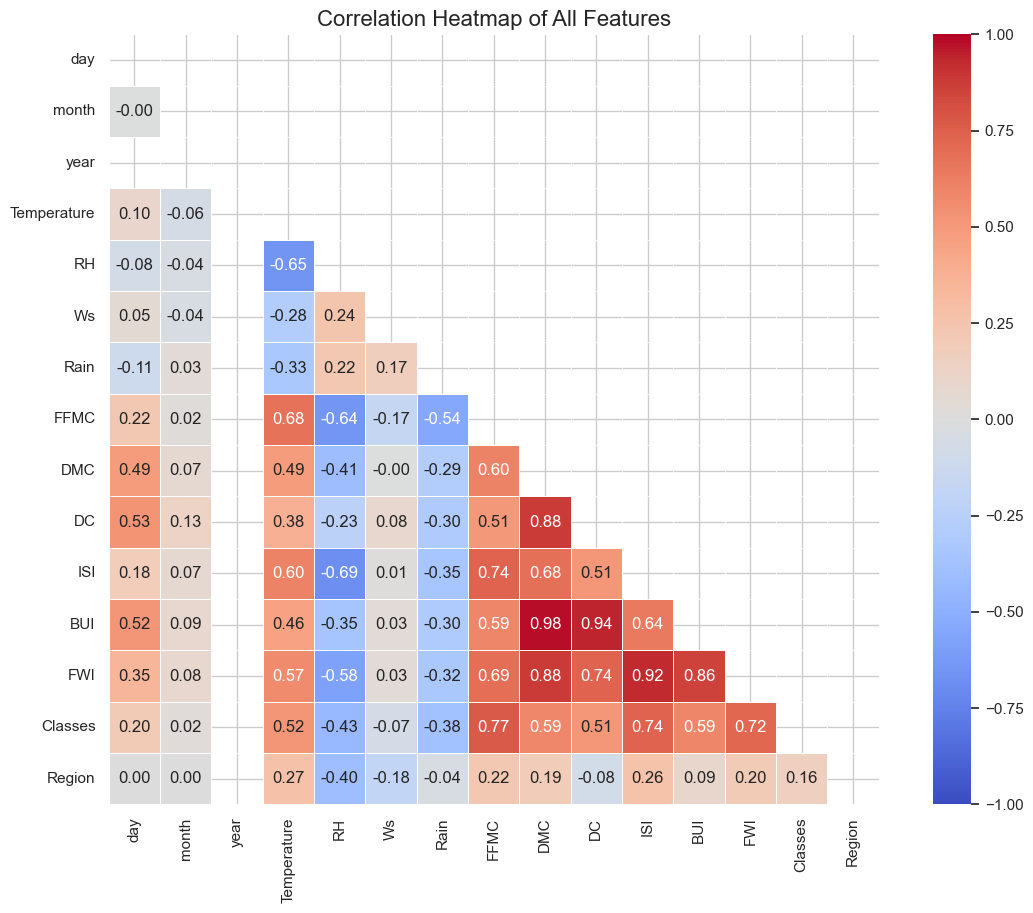

In [9]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.show()


**What the graph shows:** A lower-triangle correlation heatmap utilizing Pearson's correlation coefficient. Dark red indicates strong positive correlation, while dark blue indicates strong negative correlation.

**Patterns/Trends:** 
- `Classes` has a strong positive correlation with `Temperature`, `FFMC`, `ISI`, and `FWI`, and a strong negative correlation with `RH`.
- There is severe multicollinearity among the indices: `BUI` is almost perfectly correlated with `DMC` (0.98) and `DC` (0.94). `FWI` is highly correlated with `ISI` (0.92) and `BUI` (0.86).

**ML Implications:** The extreme multicollinearity among the Fire Weather Indices will cause issues for linear models like standard Linear Regression or Logistic Regression, leading to unstable coefficients. To address this, we must either:
1. Use regularization techniques (L1/Lasso or L2/Ridge).
2. Perform feature selection to drop highly correlated predictors (e.g., dropping BUI since DMC and DC contain the same variance).
3. Use Tree-based algorithms (Random Forest, XGBoost) which are immune to multicollinearity.


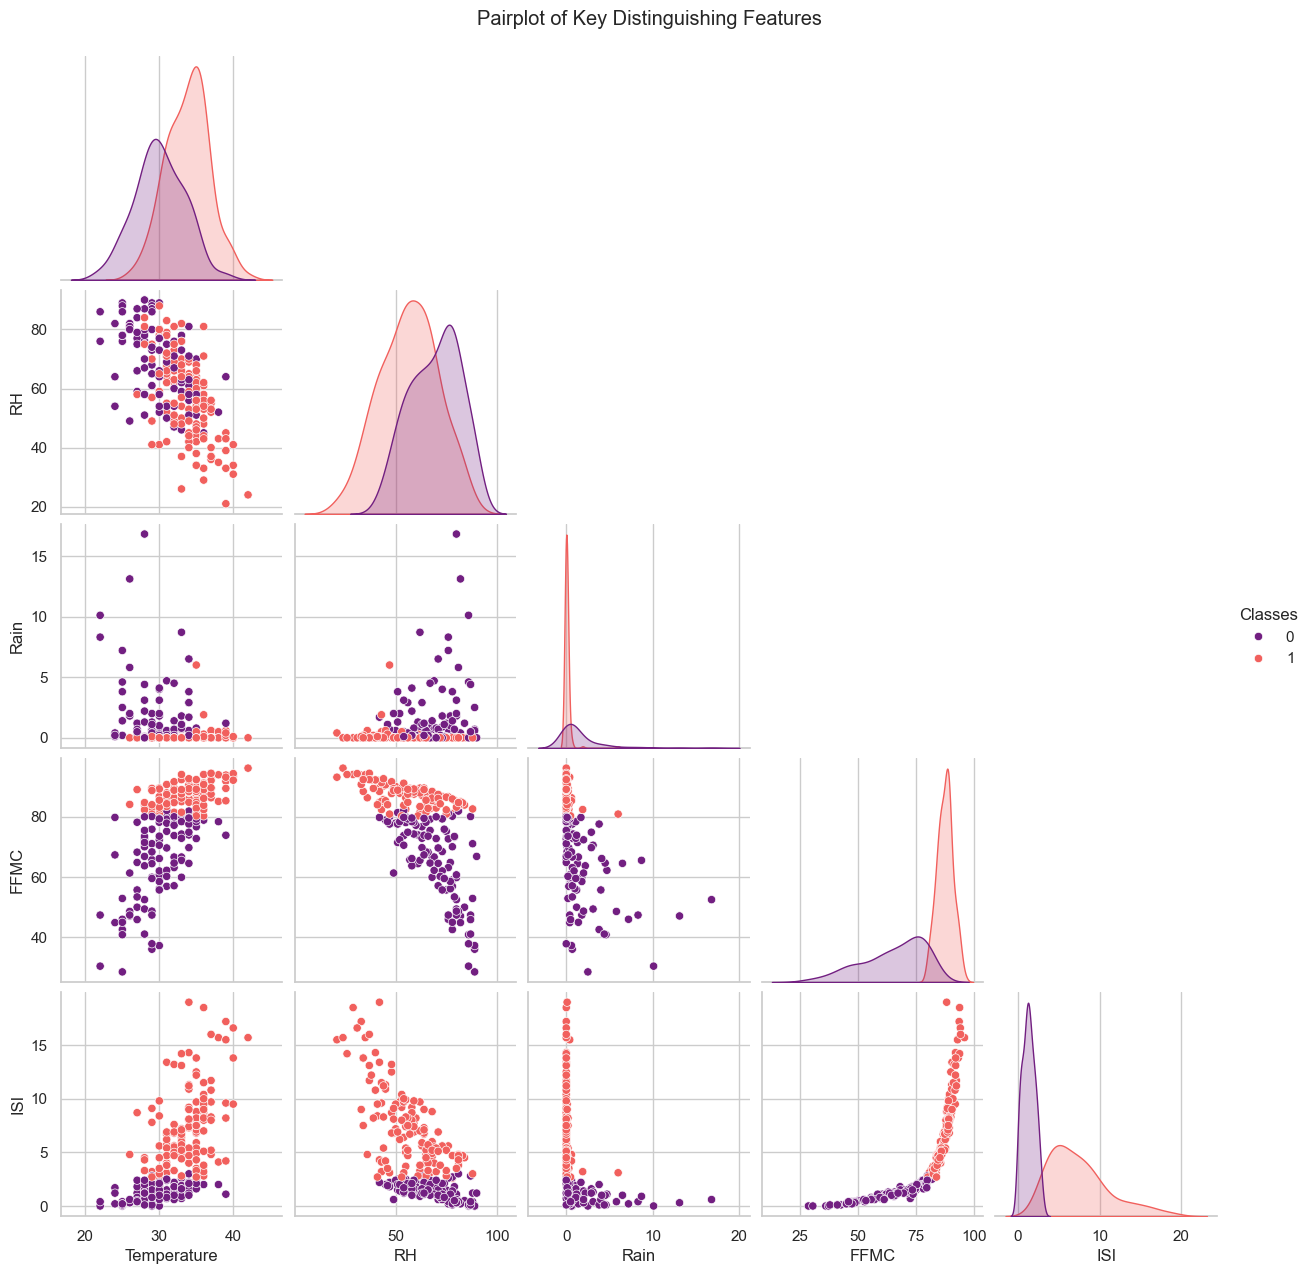

In [10]:
# Let's plot a pairplot for a subset of the most critical and distinct features
key_features = ['Temperature', 'RH', 'Rain', 'FFMC', 'ISI', 'Classes']
sns.pairplot(df[key_features], hue='Classes', palette='magma', corner=True)
plt.suptitle('Pairplot of Key Distinguishing Features', y=1.02)
plt.show()


**What the graph shows:** A scatterplot matrix (Pairplot) for a curated subset of features, color-coded by the target variable (`Classes`).

**Patterns/Trends:** The scatter plots reveal clear decision boundaries. For example, the interaction between `FFMC` and `Temperature`, or `FFMC` and `RH`, shows cleanly separated clusters of Fire (orange) vs Not Fire (purple). 

**ML Implications:** The distinct clustering confirms that the data is highly linearly separable in multi-dimensional space. Support Vector Machines (SVM) with a linear kernel or standard Logistic Regression will likely excel at this classification task.


# Key Insights

Following a rigorous exploratory data analysis (utilizing the ml-eda-pro workflow), we have identified several critical directives for our upcoming feature engineering and modeling phases:

1.  **Balanced Classes:** The target variable is well-balanced (~56% vs ~44%). We do not require synthetic oversampling like SMOTE, and accuracy will be a reliable primary metric.
2.  **High Separability:** The target variable is easily distinguishable using combinations of meteorological features and fire indices, meaning our models should achieve high performance.
3.  **Skewness and Outliers:** Several numerical features (especially `Rain` and the FWI indices) are highly skewed and contain real-world outliers. We must employ Robust Scaling or standardizations.
4.  **Severe Multicollinearity:** The Fire Weather Indices (`BUI`, `DMC`, `DC`, `FWI`) are heavily intercorrelated. We must mitigate this by applying L1/L2 Regularization, performing manual feature selection, or leveraging tree-based ensemble methods that are inherently resistant to collinearity.
